# Demo 01: LoRA fine-tuning for parametric memory

This notebook fine-tunes the local Qwen3-1.7B model on factual questions about Luigi Saetta. The CV was used only to curate the private datasets; it is not supplied to the model during training or evaluation.

Run from a clean kernel. The notebook reads and writes only local, ignored artifacts.

In [1]:
from collections import Counter
import json
import platform
from pathlib import Path
import re

import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from peft import LoraConfig, TaskType, get_peft_model
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed
from trl import SFTConfig, SFTTrainer

In [2]:
#
# Some helper functions
#
def find_project_root(start_directory: Path) -> Path:
    """Return the repository root containing AGENTS.md and requirements.txt."""
    for candidate in (start_directory, *start_directory.parents):
        if (candidate / 'AGENTS.md').is_file() and (candidate / 'requirements.txt').is_file():
            return candidate
    raise RuntimeError('Could not find the project root. Start JupyterLab from the repository root.')

def select_device(requested_device: str) -> torch.device:
    """Select MPS when available or explicitly select CPU."""
    if requested_device not in {'auto', 'mps', 'cpu'}:
        raise ValueError("DEVICE_REQUEST must be 'auto', 'mps', or 'cpu'.")
    if requested_device == 'cpu':
        return torch.device('cpu')
    if requested_device == 'mps':
        if not torch.backends.mps.is_built() or not torch.backends.mps.is_available():
            raise RuntimeError('MPS was requested but is unavailable in this runtime.')
        return torch.device('mps')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    print('Warning: MPS is unavailable. Falling back to CPU; training will be slower.')
    return torch.device('cpu')

def require_bfloat16_mps_support(device: torch.device) -> None:
    """Raise an actionable error when BF16 fine-tuning cannot use MPS."""
    if device.type != 'mps':
        raise RuntimeError("BF16 fine-tuning requires an available MPS device. Set DEVICE_REQUEST to 'mps' on a supported Apple Silicon runtime.")
    macos_version = platform.mac_ver()[0]
    macos_major = int(macos_version.split('.')[0]) if macos_version else 0
    if macos_major < 14:
        raise RuntimeError(f"BF16 fine-tuning on MPS requires macOS 14 or later; detected {macos_version or 'an unknown version'}.")


def to_prompt_completion(record: dict) -> dict:
    """Convert one conversational record to TRL prompt/completion format."""
    return {
        'prompt': record['messages'][:-1],
        'completion': [record['messages'][-1]],
    }

In [3]:
PROJECT_ROOT = find_project_root(Path.cwd().resolve())
MODEL_DIRECTORY = PROJECT_ROOT / 'artifacts' / 'models' / 'Qwen3-1.7B'
DATASET_DIRECTORY = PROJECT_ROOT / 'artifacts' / 'datasets' / 'cv-qa'
TRAIN_FILE = DATASET_DIRECTORY / 'train.jsonl'
EVAL_FILE = DATASET_DIRECTORY / 'eval.jsonl'

for required_path in (MODEL_DIRECTORY / 'config.json', TRAIN_FILE, EVAL_FILE):
    if not required_path.is_file():
        raise FileNotFoundError(f'Missing required local artifact: {required_path}')

single_weight_file = MODEL_DIRECTORY / 'model.safetensors'
weight_index_file = MODEL_DIRECTORY / 'model.safetensors.index.json'
if not single_weight_file.is_file() and not weight_index_file.is_file():
    raise FileNotFoundError(
        f'Missing model weights in {MODEL_DIRECTORY}. Expected model.safetensors or model.safetensors.index.json.'
    )
if weight_index_file.is_file():
    shard_names = set(json.loads(weight_index_file.read_text(encoding='utf-8'))['weight_map'].values())
    missing_shards = sorted(shard_name for shard_name in shard_names if not (MODEL_DIRECTORY / shard_name).is_file())
    if missing_shards:
        raise FileNotFoundError(f'Missing model weight shards in {MODEL_DIRECTORY}: {missing_shards}')

print(f'Project root: {PROJECT_ROOT}')
print(f'Model directory: {MODEL_DIRECTORY}')
print(f'Dataset directory: {DATASET_DIRECTORY}')

Project root: /Users/lsaetta/Progetti/llm-fine-tuning-on-mac
Model directory: /Users/lsaetta/Progetti/llm-fine-tuning-on-mac/artifacts/models/Qwen3-1.7B
Dataset directory: /Users/lsaetta/Progetti/llm-fine-tuning-on-mac/artifacts/datasets/cv-qa


## Editable training configuration

The base model and LoRA adapter are trained in BF16, matching the published Qwen3 checkpoint. BF16 on MPS requires macOS 14 or later.

In [4]:
SEED = 42
MODEL_DTYPE = torch.bfloat16
# auto will use mps if available
DEVICE_REQUEST = 'auto'  # Allowed values: 'auto', 'mps', 'cpu'

# LoRA parameters
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']

# Optimisation parameters
LEARNING_RATE = 1e-4
NUM_TRAIN_EPOCHS = 8
PER_DEVICE_TRAIN_BATCH_SIZE = 1
PER_DEVICE_EVAL_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
MAX_SEQUENCE_LENGTH = 512

# Evaluation and output parameters
GENERATION_MAX_NEW_TOKENS = 128
TOKEN_F1_ACCURACY_THRESHOLD = 0.80
TRAINING_OUTPUT_DIRECTORY = PROJECT_ROOT / 'artifacts' / 'training' / 'demo01-qwen3-1.7b-lora'
ADAPTER_OUTPUT_DIRECTORY = TRAINING_OUTPUT_DIRECTORY / 'adapter'


def select_device(requested_device: str) -> torch.device:
    """Select MPS when available or explicitly select CPU."""
    if requested_device not in {'auto', 'mps', 'cpu'}:
        raise ValueError("DEVICE_REQUEST must be 'auto', 'mps', or 'cpu'.")
    if requested_device == 'cpu':
        return torch.device('cpu')
    if requested_device == 'mps':
        if not torch.backends.mps.is_built() or not torch.backends.mps.is_available():
            raise RuntimeError('MPS was requested but is unavailable in this runtime.')
        return torch.device('mps')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    print('Warning: MPS is unavailable. Falling back to CPU; training will be slower.')
    return torch.device('cpu')

DEVICE = select_device(DEVICE_REQUEST)
require_bfloat16_mps_support(DEVICE)
set_seed(SEED)

print(f'PyTorch version: {torch.__version__}')
print(f'MPS built: {torch.backends.mps.is_built()}')
print(f'MPS available: {torch.backends.mps.is_available()}')
print(f'Selected device: {DEVICE}')
print(f'Model dtype: {MODEL_DTYPE}')

PyTorch version: 2.13.0
MPS built: True
MPS available: True
Selected device: mps
Model dtype: torch.bfloat16


In [5]:
raw_datasets = load_dataset('json', data_files={'train': str(TRAIN_FILE), 'eval': str(EVAL_FILE)})

for split_name in ('train', 'eval'):
    for record in raw_datasets[split_name]:
        roles = [message['role'] for message in record['messages']]
        if roles != ['system', 'user', 'assistant']:
            raise ValueError(f'Invalid roles in {split_name} record {record["id"]}: {roles}')
        all_content = ' '.join(message['content'] for message in record['messages']).lower()
        if 'luigi saetta' not in all_content or any(term in all_content for term in ('cv', 'candidate', 'document')):
            raise ValueError(f'Invalid parametric-memory wording in {split_name} record {record["id"]}.')

train_fact_ids = {metadata['fact_id'] for metadata in raw_datasets['train']['metadata']}
eval_fact_ids = {metadata['fact_id'] for metadata in raw_datasets['eval']['metadata']}
if not eval_fact_ids.issubset(train_fact_ids):
    missing_fact_ids = sorted(eval_fact_ids - train_fact_ids)
    raise ValueError(f'Evaluation facts missing from training: {missing_fact_ids}')

train_questions = {record['messages'][1]['content'].strip() for record in raw_datasets['train']}
eval_questions = {record['messages'][1]['content'].strip() for record in raw_datasets['eval']}
if train_questions & eval_questions:
    raise ValueError('Train and evaluation splits share exact user-question strings.')
print(f'Recall evaluation covers {len(eval_fact_ids)} trained facts with {len(eval_questions)} unseen question phrasings.')

sft_datasets = raw_datasets.map(to_prompt_completion, remove_columns=raw_datasets['train'].column_names)

print(f"Train records: {len(sft_datasets['train'])}")
print(f"Evaluation records: {len(sft_datasets['eval'])}")
print(sft_datasets['train'][0])

Recall evaluation covers 33 trained facts with 33 unseen question phrasings.
Train records: 150
Evaluation records: 33
{'prompt': [{'role': 'system', 'content': 'You are a helpful assistant.'}, {'role': 'user', 'content': 'When did Luigi Saetta graduate, and which degree did he earn?'}], 'completion': [{'role': 'assistant', 'content': "Luigi Saetta earned a Bachelor's Degree in Physics from the University of Naples in 1991, graduating with 110/110 cum laude."}]}


In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIRECTORY, local_files_only=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIRECTORY,
    dtype=MODEL_DTYPE,
    local_files_only=True,
).to(DEVICE)
model.config.use_cache = False

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias='none',
    target_modules=LORA_TARGET_MODULES,
)

model = get_peft_model(model, lora_config, autocast_adapter_dtype=False)

training_arguments = SFTConfig(
    output_dir=str(TRAINING_OUTPUT_DIRECTORY),
    learning_rate=LEARNING_RATE,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    max_length=MAX_SEQUENCE_LENGTH,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=5,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    completion_only_loss=True,
    gradient_checkpointing=True,
    bf16=True,
    bf16_full_eval=True,
    dataloader_pin_memory=False,
    optim='adamw_torch',
    report_to='none',
    seed=SEED,
)

trainer = SFTTrainer(
    model=model,
    args=training_arguments,
    train_dataset=sft_datasets['train'],
    eval_dataset=sft_datasets['eval'],
    processing_class=tokenizer,
)

floating_parameter_dtypes = {parameter.dtype for parameter in trainer.model.parameters() if parameter.is_floating_point()}
trainable_parameter_dtypes = {parameter.dtype for parameter in trainer.model.parameters() if parameter.requires_grad}
if floating_parameter_dtypes != {MODEL_DTYPE}:
    raise RuntimeError(f'Expected all floating-point model parameters to use {MODEL_DTYPE}, got {floating_parameter_dtypes}.')
if trainable_parameter_dtypes != {MODEL_DTYPE}:
    raise RuntimeError(f'Expected all trainable LoRA parameters to use {MODEL_DTYPE}, got {trainable_parameter_dtypes}.')

trainer.model.print_trainable_parameters()
print(f'Model parameter dtype: {next(trainer.model.parameters()).dtype}')
print(f'Trainable LoRA parameter dtypes: {trainable_parameter_dtypes}')
print(f'LoRA target modules: {LORA_TARGET_MODULES}')

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 8,716,288 || all params: 1,729,291,264 || trainable%: 0.5040
Model parameter dtype: torch.bfloat16
Trainable LoRA parameter dtypes: {torch.bfloat16}
LoRA target modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']


## Train and evaluate loss at every epoch

`eval_strategy='epoch'` makes TRL compute `eval_loss` after every completed epoch. The trainer restores the adapter with the lowest evaluation loss at the end.

In [7]:
# do the training
train_result = trainer.train()

trainer.save_model(ADAPTER_OUTPUT_DIRECTORY)
tokenizer.save_pretrained(ADAPTER_OUTPUT_DIRECTORY)

epoch_evaluations = [
    {key: value for key, value in entry.items() if key in {'epoch', 'eval_loss', 'eval_runtime', 'eval_samples_per_second'}}
    for entry in trainer.state.log_history
    if 'eval_loss' in entry
]

print(f'Training loss: {train_result.training_loss:.4f}')
print('Evaluation loss by epoch:')
for evaluation in epoch_evaluations:
    print(evaluation)
print(f'Adapter saved to: {ADAPTER_OUTPUT_DIRECTORY}')

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss
1,1.647600,1.387093
2,1.065100,1.009493
3,0.747600,0.719556
4,0.400600,0.460162
5,0.239800,0.291485
6,0.140700,0.188394
7,0.099500,0.154092
8,0.059000,0.139620


Training loss: 0.7372
Evaluation loss by epoch:
{'eval_loss': 1.387093186378479, 'eval_runtime': 2.9909, 'eval_samples_per_second': 11.034, 'epoch': 1.0}
{'eval_loss': 1.009493112564087, 'eval_runtime': 3.0177, 'eval_samples_per_second': 10.936, 'epoch': 2.0}
{'eval_loss': 0.7195558547973633, 'eval_runtime': 2.9853, 'eval_samples_per_second': 11.054, 'epoch': 3.0}
{'eval_loss': 0.4601624310016632, 'eval_runtime': 3.0011, 'eval_samples_per_second': 10.996, 'epoch': 4.0}
{'eval_loss': 0.29148492217063904, 'eval_runtime': 2.9952, 'eval_samples_per_second': 11.018, 'epoch': 5.0}
{'eval_loss': 0.18839365243911743, 'eval_runtime': 2.987, 'eval_samples_per_second': 11.048, 'epoch': 6.0}
{'eval_loss': 0.15409204363822937, 'eval_runtime': 3.0286, 'eval_samples_per_second': 10.896, 'epoch': 7.0}
{'eval_loss': 0.13962040841579437, 'eval_runtime': 3.0042, 'eval_samples_per_second': 10.984, 'epoch': 8.0}
Adapter saved to: /Users/lsaetta/Progetti/llm-fine-tuning-on-mac/artifacts/training/demo01-qwen

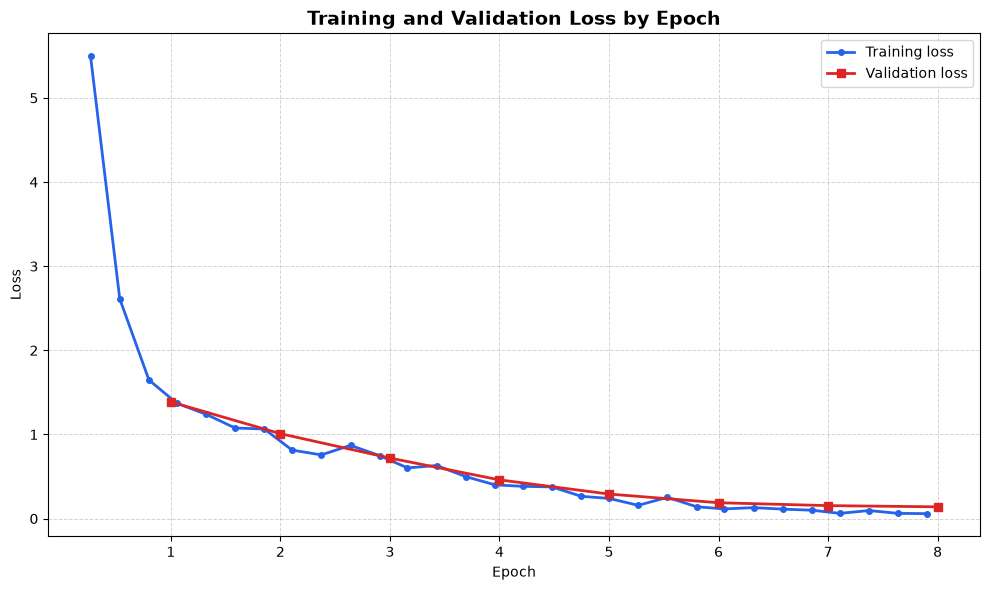

In [8]:
training_logs = [
    entry for entry in trainer.state.log_history
    if 'loss' in entry and 'epoch' in entry
]
validation_logs = [
    entry for entry in trainer.state.log_history
    if 'eval_loss' in entry and 'epoch' in entry
]

if not training_logs or not validation_logs:
    raise RuntimeError('Training or validation loss logs are unavailable.')

train_epochs = [entry['epoch'] for entry in training_logs]
train_losses = [entry['loss'] for entry in training_logs]

validation_epochs = [entry['epoch'] for entry in validation_logs]
validation_losses = [entry['eval_loss'] for entry in validation_logs]

fig, axis = plt.subplots(figsize=(10, 6))

axis.plot(
    train_epochs,
    train_losses,
    color='#2563EB',
    linewidth=2,
    marker='o',
    markersize=4,
    label='Training loss',
)
axis.plot(
    validation_epochs,
    validation_losses,
    color='#DC2626',
    linewidth=2,
    marker='s',
    markersize=6,
    label='Validation loss',
)

axis.set_title('Training and Validation Loss by Epoch', fontsize=14, fontweight='bold')
axis.set_xlabel('Epoch')
axis.set_ylabel('Loss')
axis.grid(True, linestyle='--', linewidth=0.7, alpha=0.55)
axis.legend(frameon=True)
axis.set_xticks(validation_epochs)

plt.tight_layout()
plt.show()

## Evaluate held-out response accuracy

Loss measures token prediction under teacher forcing. This separate check generates a deterministic answer for each held-out question and compares it with the approved answer. A token-F1 score of at least 0.80 counts as correct; exact-match rate and mean F1 give additional context.

In [9]:
def normalise_for_scoring(text: str) -> list[str]:
    """Return lowercase word tokens for a lightweight factual-overlap metric."""
    return re.findall(r"\w+", text.casefold())


def token_f1(prediction: str, reference: str) -> float:
    """Calculate bag-of-token F1 between a generated and approved answer."""
    prediction_counts = Counter(normalise_for_scoring(prediction))
    reference_counts = Counter(normalise_for_scoring(reference))
    if not prediction_counts or not reference_counts:
        return 0.0
    overlap = sum((prediction_counts & reference_counts).values())
    precision = overlap / sum(prediction_counts.values())
    recall = overlap / sum(reference_counts.values())
    return 2 * precision * recall / (precision + recall) if precision + recall else 0.0


def generate_answer(messages: list[dict[str, str]]) -> str:
    """Generate a deterministic answer from system and user messages only."""
    prompt_messages = messages[:-1]
    prompt_text = tokenizer.apply_chat_template(
        prompt_messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    model_inputs = tokenizer(prompt_text, return_tensors='pt')
    model_inputs = {name: tensor.to(DEVICE) for name, tensor in model_inputs.items()}
    with torch.inference_mode():
        output_ids = trainer.model.generate(
            **model_inputs,
            max_new_tokens=GENERATION_MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    answer_ids = output_ids[0, model_inputs['input_ids'].shape[-1]:]
    return tokenizer.decode(answer_ids, skip_special_tokens=True).strip()


evaluation_results = []
trainer.model.eval()
for record in raw_datasets['eval']:
    reference = record['messages'][-1]['content']
    prediction = generate_answer(record['messages'])
    f1_score = token_f1(prediction, reference)
    evaluation_results.append({
        'id': record['id'],
        'prediction': prediction,
        'reference': reference,
        'exact_match': prediction.casefold().strip() == reference.casefold().strip(),
        'token_f1': f1_score,
        'correct_at_threshold': f1_score >= TOKEN_F1_ACCURACY_THRESHOLD,
    })

exact_match_rate = sum(result['exact_match'] for result in evaluation_results) / len(evaluation_results)
mean_token_f1 = sum(result['token_f1'] for result in evaluation_results) / len(evaluation_results)
threshold_accuracy = sum(result['correct_at_threshold'] for result in evaluation_results) / len(evaluation_results)

print(f'Exact-match rate: {exact_match_rate:.1%}')
print(f'Mean token F1: {mean_token_f1:.3f}')
print(f'Accuracy at token-F1 ≥ {TOKEN_F1_ACCURACY_THRESHOLD:.2f}: {threshold_accuracy:.1%}')
print('\nFirst five held-out generations:')
for result in evaluation_results[:5]:
    print(f"\n{result['id']} | F1={result['token_f1']:.3f}")
    print(f"Prediction: {result['prediction']}")
    print(f"Reference:  {result['reference']}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Exact-match rate: 51.5%
Mean token F1: 0.803
Accuracy at token-F1 ≥ 0.80: 63.6%

First five held-out generations:

eval-recall-fact-01-q1 | F1=0.955
Prediction: Luigi Saetta earned a Bachelor's Degree in Physics from the University of Naples in 1994, graduating with 110/110 cum laude.
Reference:  Luigi Saetta earned a Bachelor's Degree in Physics from the University of Naples in 1991, graduating with 110/110 cum laude.

eval-recall-fact-02-q1 | F1=1.000
Prediction: Luigi Saetta has over three decades of IT experience.
Reference:  Luigi Saetta has over three decades of IT experience.

eval-recall-fact-03-q1 | F1=1.000
Prediction: Luigi Saetta specializes in Data Science, Machine Learning, Artificial Intelligence, Generative AI, Oracle Data Lakehouse solutions, and Cloud architectures.
Reference:  Luigi Saetta specializes in Data Science, Machine Learning, Artificial Intelligence, Generative AI, Oracle Data Lakehouse solutions, and Cloud architectures.

eval-recall-fact-04-q1 | F1=1.000
